<a href="https://colab.research.google.com/github/Janpu-Hou/Green-Learning-Basic/blob/main/GLBasic2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder, PowerTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import lightgbm as lgb

# =====================================================================
# MODULE 1: UNSUPERVISED REPRESENTATION LEARNING (SAAB TRANSFORM)
# =====================================================================
class TabularSaabTransform(BaseEstimator, TransformerMixin):
    def __init__(self, k_prime=0.95):
        self.k_prime = k_prime
        self.scaler = StandardScaler()
        self.pca = None
        self.bias_vector_ = None

    def fit(self, X, y=None):
        X_scaled = self.scaler.fit_transform(X)
        self.pca = PCA(n_components=self.k_prime, random_state=42)
        self.pca.fit(X_scaled)
        raw_responses = np.dot(X_scaled, self.pca.components_.T)
        self.bias_vector_ = np.abs(np.min(raw_responses, axis=0)) + 1e-5
        return self

    def transform(self, X):
        X_scaled = self.scaler.transform(X)
        ac_responses = np.dot(X_scaled, self.pca.components_.T)
        return ac_responses + self.bias_vector_

# =====================================================================
# MODULE 2: SUPERVISED FEATURE LEARNING (MULTI-CLASS DFT)
# =====================================================================
class MultiClassDiscriminantFeatureTest(BaseEstimator, TransformerMixin):
    def __init__(self, percentile_threshold=80):  # 保留 80% 的關鍵特徵
        self.percentile_threshold = percentile_threshold
        self.selected_indices_ = []

    def _calculate_entropy(self, y):
        if len(y) == 0:
            return 0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return -np.sum(probs * np.log2(probs + 1e-9))

    def fit(self, X, y):
        num_features = X.shape[1]
        feature_costs = []
        y = np.array(y)
        for i in range(num_features):
            f_col = X[:, i]
            thresholds = np.percentile(f_col, [10, 25, 50, 75, 90])
            best_entropy = float('inf')
            for t in thresholds:
                left_mask = f_col < t
                right_mask = ~left_mask
                y_left, y_right = y[left_mask], y[right_mask]
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                w_left, w_right = len(y_left) / len(y), len(y_right) / len(y)
                entropy_split = w_left * self._calculate_entropy(y_left) + w_right * self._calculate_entropy(y_right)
                if entropy_split < best_entropy:
                    best_entropy = entropy_split
            feature_costs.append(best_entropy if best_entropy != float('inf') else 999)

        cost_cutoff = np.percentile(feature_costs, self.percentile_threshold)
        self.selected_indices_ = [idx for idx, cost in enumerate(feature_costs) if cost <= cost_cutoff]
        return self

    def transform(self, X):
        return X[:, self.selected_indices_]

# =====================================================================
# COMPREHENSIVE PIPELINE WRAPPER
# =====================================================================
def run_multi_class_green_learning(train_path, test_path):
    print("Step 0: Loading Data & Preprocessing...")
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    for df in [train_df, test_df]:
        if 'attack_cat' in df.columns:
            df['attack_cat'] = df['attack_cat'].str.strip().fillna('Normal')
            df.loc[df['attack_cat'] == '', 'attack_cat'] = 'Normal'

    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(train_df['attack_cat'])
    y_test = label_encoder.transform(test_df['attack_cat'])

    cols_to_drop = ['id', 'label', 'attack_cat']
    X_train_raw = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])
    X_test_raw = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns])

    categorical_cols = X_train_raw.select_dtypes(include=['object']).columns.tolist()
    X_combined = pd.concat([X_train_raw, X_test_raw], axis=0)
    X_combined_encoded = pd.get_dummies(X_combined, columns=categorical_cols, drop_first=True)

    # 數值對數轉換 (Log Transformation - 解決 UNSW-NB15 的數值偏態問題)
    numeric_cols = [c for c in X_combined_encoded.columns if X_combined_encoded[c].dtype in [np.float64, np.int64]]
    X_combined_encoded[numeric_cols] = np.log1p(np.maximum(0, X_combined_encoded[numeric_cols]))

    X_train_numeric = X_combined_encoded.iloc[:len(X_train_raw)].values.astype(np.float64)
    X_test_numeric = X_combined_encoded.iloc[len(X_train_raw):].values.astype(np.float64)

    print(f" -> Processed Feature Shape: {X_train_numeric.shape}")

    # --- Module 1: Subspace Compression ---
    print("\nStep 1: Commencing Saab Transform (95% variance)...")
    saab = TabularSaabTransform(k_prime=0.95)
    X_train_rep = saab.fit_transform(X_train_numeric)
    X_test_rep = saab.transform(X_test_numeric)
    print(f" -> Saab Reduced Shape: {X_train_rep.shape}")

    # --- Module 2: Multi-Class Filtering ---
    print("\nStep 2: Executing Multi-Class DFT Feature Selection (Retain Top 80%)...")
    dft = MultiClassDiscriminantFeatureTest(percentile_threshold=80)
    X_train_features = dft.fit_transform(X_train_rep, y_train)
    X_test_features = dft.transform(X_test_rep)
    print(f" -> DFT Filtered Feature Shape: {X_train_features.shape}")

    # --- Module 3: LightGBM / Balanced Classifier ---
    print("\nStep 3: Training LightGBM Classifier with Class Weights...")
    classifier = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        class_weight='balanced',  # 自動加權，不破壞空間分佈
        random_state=42,
        n_jobs=-1
    )
    classifier.fit(X_train_features, y_train)

    # Final Metrics Generation
    predictions = classifier.predict(X_test_features)
    print("\n================ MULTI-CLASS GREEN LEARNING EVALUATION ================")
    print(f"Overall Testing Pipeline Accuracy: {accuracy_score(y_test, predictions):.4f}")
    print("\nDetailed Per-Class Category Threat Analysis:")
    print(classification_report(y_test, predictions, target_names=label_encoder.classes_, zero_division=0))

    return label_encoder, y_test, predictions, classifier, X_combined_encoded.columns

if __name__ == "__main__":
    train_file = "UNSW_NB15_training-set.csv"
    test_file = "UNSW_NB15_testing-set.csv"
    label_encoder, y_test, predictions, classifier, X_combined_encoded_cols = run_multi_class_green_learning(train_file, test_file)

Step 0: Loading Data & Preprocessing...
 -> Processed Feature Shape: (175341, 193)

Step 1: Commencing Saab Transform (95% variance)...
 -> Saab Reduced Shape: (175341, 144)

Step 2: Executing Multi-Class DFT Feature Selection (Retain Top 80%)...
 -> DFT Filtered Feature Shape: (175341, 115)

Step 3: Training LightGBM Classifier with Class Weights...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.233631 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 28898
[LightGBM] [Info] Number of data points in the train set: 175341, number of used features: 115
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start trainin

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



================ MULTI-CLASS GREEN LEARNING EVALUATION ================
Overall Testing Pipeline Accuracy: 0.6710

Detailed Per-Class Category Threat Analysis:
                precision    recall  f1-score   support

      Analysis       0.01      0.03      0.01       677
      Backdoor       0.05      0.53      0.09       583
           DoS       0.29      0.19      0.23      4089
      Exploits       0.74      0.59      0.65     11132
       Fuzzers       0.19      0.46      0.27      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.95      0.63      0.76     37000
Reconnaissance       0.72      0.84      0.78      3496
     Shellcode       0.23      0.73      0.35       378
         Worms       0.39      0.16      0.23        44

      accuracy                           0.67     82332
     macro avg       0.46      0.51      0.44     82332
  weighted avg       0.82      0.67      0.72     82332



Confusion Matrix:


,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Normal,Reconnaissance,Shellcode,Worms
Analysis,17,389,212,28,6,0,25,0,0,0
Backdoor,17,310,219,17,6,0,2,4,8,0
DoS,157,2324,774,618,93,1,23,40,59,0
Exploits,222,2423,809,6537,445,13,132,366,180,5
Fuzzers,39,812,418,339,2782,2,1123,194,353,0
Generic,9,20,124,370,83,18221,10,12,20,2
Normal,1163,2,93,762,10878,4,23397,464,234,3
Reconnaissance,23,286,35,113,49,1,7,2921,61,0
Shellcode,0,1,11,17,35,0,2,34,277,1
Worms,0,0,0,29,4,1,0,0,3,7


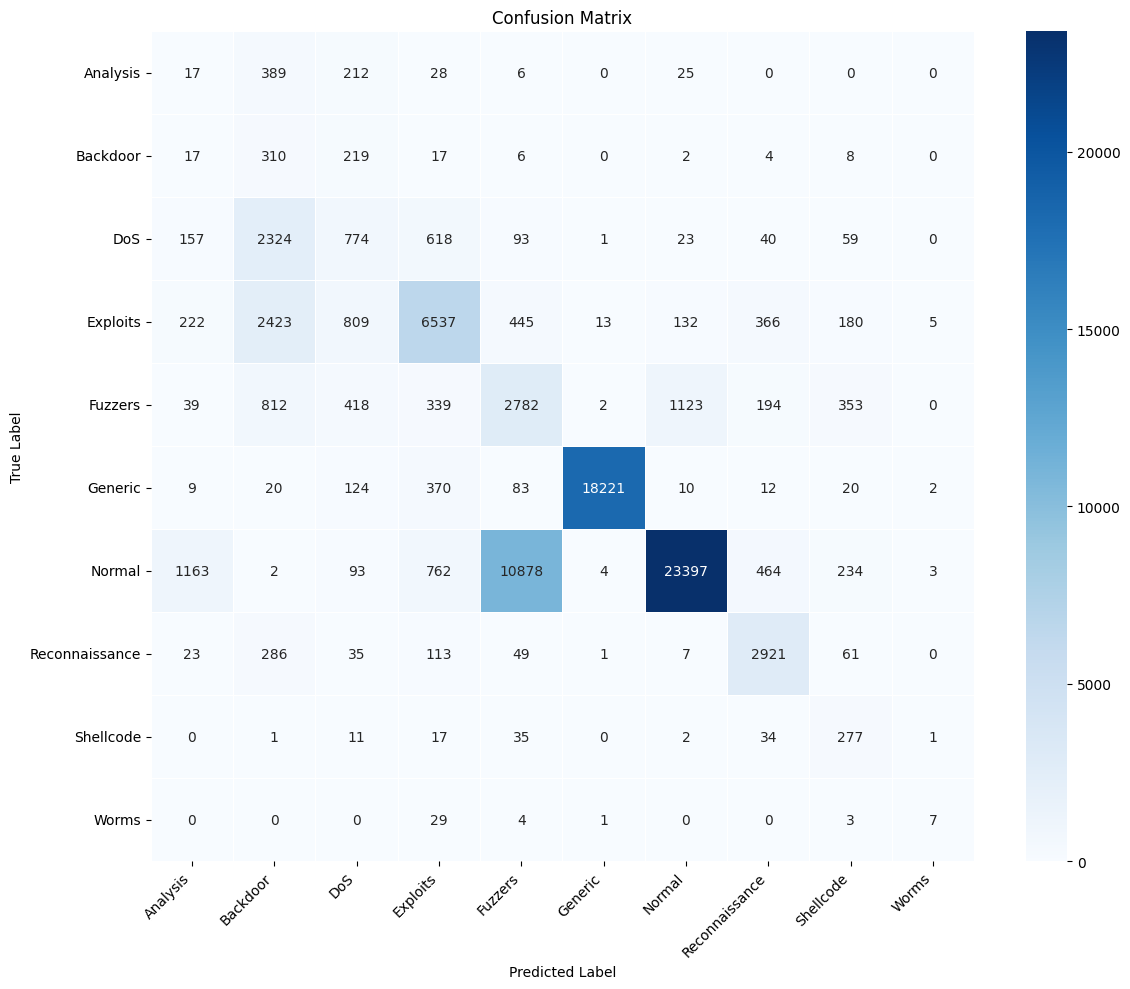


--- False Positives for 'Analysis' ---
Normal            1163
Exploits           222
DoS                157
Fuzzers             39
Reconnaissance      23
Backdoor            17
Generic              9
Name: Analysis, dtype: int64

--- False Positives for 'Backdoor' ---
Exploits          2423
DoS               2324
Fuzzers            812
Analysis           389
Reconnaissance     286
Generic             20
Normal               2
Shellcode            1
Name: Backdoor, dtype: int64


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get class names from the label encoder
class_names = label_encoder.classes_

# Compute the confusion matrix
cm = confusion_matrix(y_test, predictions)

# Create a DataFrame for better visualization
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print("Confusion Matrix:")
display(cm_df)

# Plotting the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True, linewidths=.5)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Analyzing False Positives for 'Analysis' and 'Backdoor' ---
analysis_idx = label_encoder.transform(['Analysis'])[0]
backdoor_idx = label_encoder.transform(['Backdoor'])[0]

print("\n--- False Positives for 'Analysis' ---")
# Identify rows where 'Analysis' was *predicted* (column 'Analysis') but was *not* the true label (other rows)
# cm[:, analysis_idx] gives the column for 'Analysis' predictions
# We exclude the diagonal element (true positives for Analysis)
false_positives_analysis = cm_df.drop(index='Analysis')['Analysis']
print(false_positives_analysis[false_positives_analysis > 0].sort_values(ascending=False))

print("\n--- False Positives for 'Backdoor' ---")
# Identify rows where 'Backdoor' was *predicted* (column 'Backdoor') but was *not* the true label (other rows)
false_positives_backdoor = cm_df.drop(index='Backdoor')['Backdoor']
print(false_positives_backdoor[false_positives_backdoor > 0].sort_values(ascending=False))

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Reload raw dataframes to apply preprocessing specifically for binary classification
train_df_raw = pd.read_csv("UNSW_NB15_training-set.csv")
test_df_raw = pd.read_csv("UNSW_NB15_testing-set.csv")

# Clean attack_cat for both dataframes (as done in run_multi_class_green_learning)
for df in [train_df_raw, test_df_raw]:
    if 'attack_cat' in df.columns:
        df['attack_cat'] = df['attack_cat'].str.strip().fillna('Normal')
        df.loc[df['attack_cat'] == '', 'attack_cat'] = 'Normal'

# Combine train and test for consistent feature processing and then filter
combined_df_raw = pd.concat([train_df_raw, test_df_raw], ignore_index=True)

# Filter for 'Backdoor' and 'Exploits' classes
target_classes = ['Backdoor', 'Exploits']
binary_df = combined_df_raw[combined_df_raw['attack_cat'].isin(target_classes)].copy()

# Prepare features (X) and target (y)
cols_to_drop_binary = ['id', 'label', 'attack_cat']
X_binary_raw = binary_df.drop(columns=[c for c in cols_to_drop_binary if c in binary_df.columns])
y_binary_raw = binary_df['attack_cat']

# Encode target labels for binary classification
binary_label_encoder = LabelEncoder()
y_binary = binary_label_encoder.fit_transform(y_binary_raw)

# Get categorical columns from the raw feature set (consistent with full pipeline)
categorical_cols_binary = X_binary_raw.select_dtypes(include=['object']).columns.tolist()

# Apply one-hot encoding
X_binary_encoded = pd.get_dummies(X_binary_raw, columns=categorical_cols_binary, drop_first=True)

# Align columns with the full dataset's encoded columns (X_combined_encoded_cols)
# This ensures that we have all features that the original model saw, even if some are all zeros for this subset.
# Fill NaN with 0 for columns that were in the original full set but not in the filtered binary set.
# X_combined_encoded_cols is available from the `run_multi_class_green_learning` execution
X_binary_processed = X_binary_encoded.reindex(columns=X_combined_encoded_cols, fill_value=0)

# Apply log transformation to numeric features in the binary dataset (consistent with full pipeline)
numeric_cols_binary = [c for c in X_binary_processed.columns if X_binary_processed[c].dtype in [np.float64, np.int64]]
X_binary_processed[numeric_cols_binary] = np.log1p(np.maximum(0, X_binary_processed[numeric_cols_binary]))

print(f"Shape of X_binary_processed for Backdoor/Exploits: {X_binary_processed.shape}")
print(f"Number of 'Backdoor' samples: {np.sum(y_binary == binary_label_encoder.transform(['Backdoor'])[0])}")
print(f"Number of 'Exploits' samples: {np.sum(y_binary == binary_label_encoder.transform(['Exploits'])[0])}")

Shape of X_binary_processed for Backdoor/Exploits: (46854, 193)
Number of 'Backdoor' samples: 2329
Number of 'Exploits' samples: 44525


Binary Training Features shape: (32797, 193)
Binary Testing Features shape: (14057, 193)
[LightGBM] [Info] Number of positive: 31167, number of negative: 1630
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007862 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6108
[LightGBM] [Info] Number of data points in the train set: 32797, number of used features: 178
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


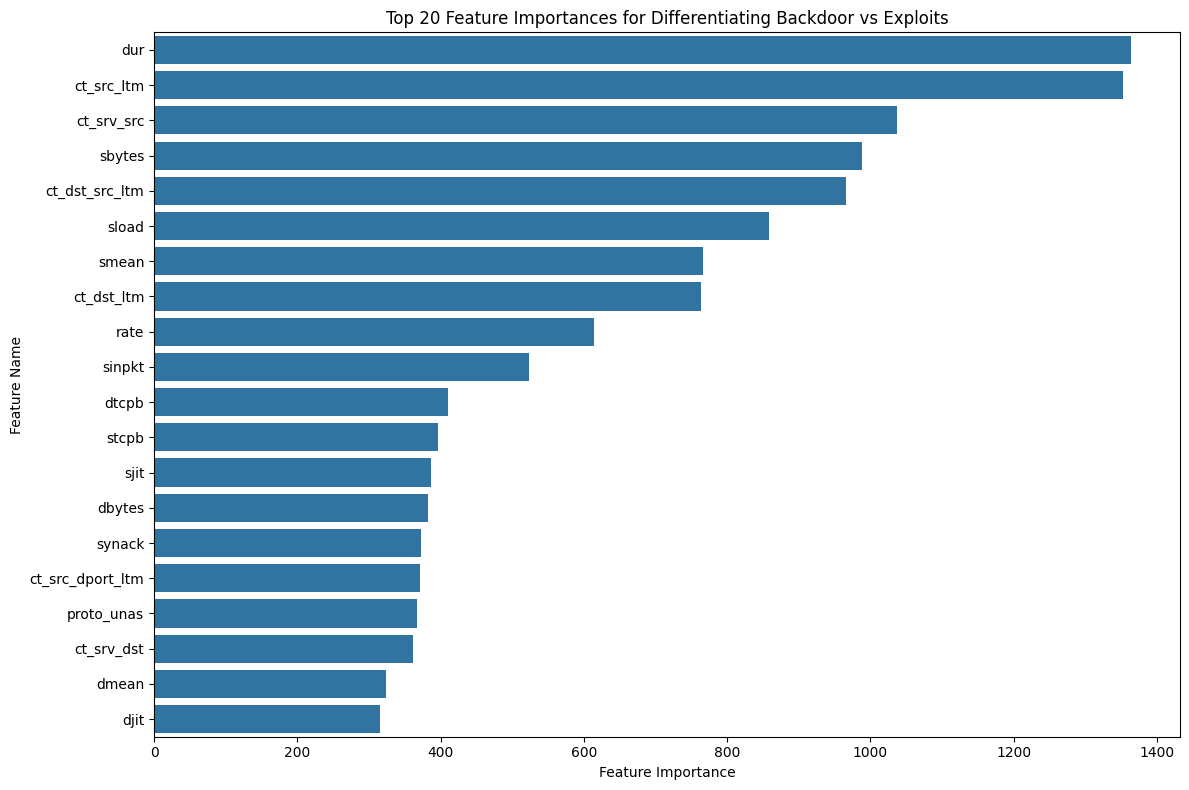


Top 20 Features differentiating 'Backdoor' vs 'Exploits':


,feature,importance
0,dur,1364
36,ct_src_ltm,1352
27,ct_srv_src,1037
3,sbytes,988
32,ct_dst_src_ltm,966
8,sload,858
23,smean,767
29,ct_dst_ltm,763
5,rate,614
12,sinpkt,523


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# Split the binary dataset into training and testing sets
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    X_binary_processed, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

print(f"Binary Training Features shape: {X_train_binary.shape}")
print(f"Binary Testing Features shape: {X_test_binary.shape}")

# Train a LightGBM classifier specifically for 'Backdoor' vs 'Exploits'
# Using class_weight='balanced' to handle potential class imbalance even in the binary subset
binary_classifier = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
binary_classifier.fit(X_train_binary, y_train_binary)

# Get feature importances
feature_importances = binary_classifier.feature_importances_
feature_names = X_binary_processed.columns

# Create a DataFrame for easy sorting and plotting
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='importance', ascending=False)

# Plot top N features (e.g., top 20)
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances for Differentiating Backdoor vs Exploits')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

# Display the top features
print("\nTop 20 Features differentiating 'Backdoor' vs 'Exploits':")
display(importance_df.head(20))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the binary_df for 'Backdoor' and 'Exploits' classes specifically
dur_backdoor = binary_df[binary_df['attack_cat'] == 'Backdoor']['dur']
dur_exploits = binary_df[binary_df['attack_cat'] == 'Exploits']['dur']

plt.figure(figsize=(10, 6))
sns.kdeplot(dur_backdoor, label='Backdoor', fill=True, alpha=0.5)
sns.kdeplot(dur_exploits, label='Exploits', fill=True, alpha=0.5)
plt.title('Distribution of "dur" (Connection Duration) for Backdoor vs Exploits')
plt.xlabel('Duration (seconds)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xscale('log') # Use log scale for duration as it often has a wide range
plt.show()


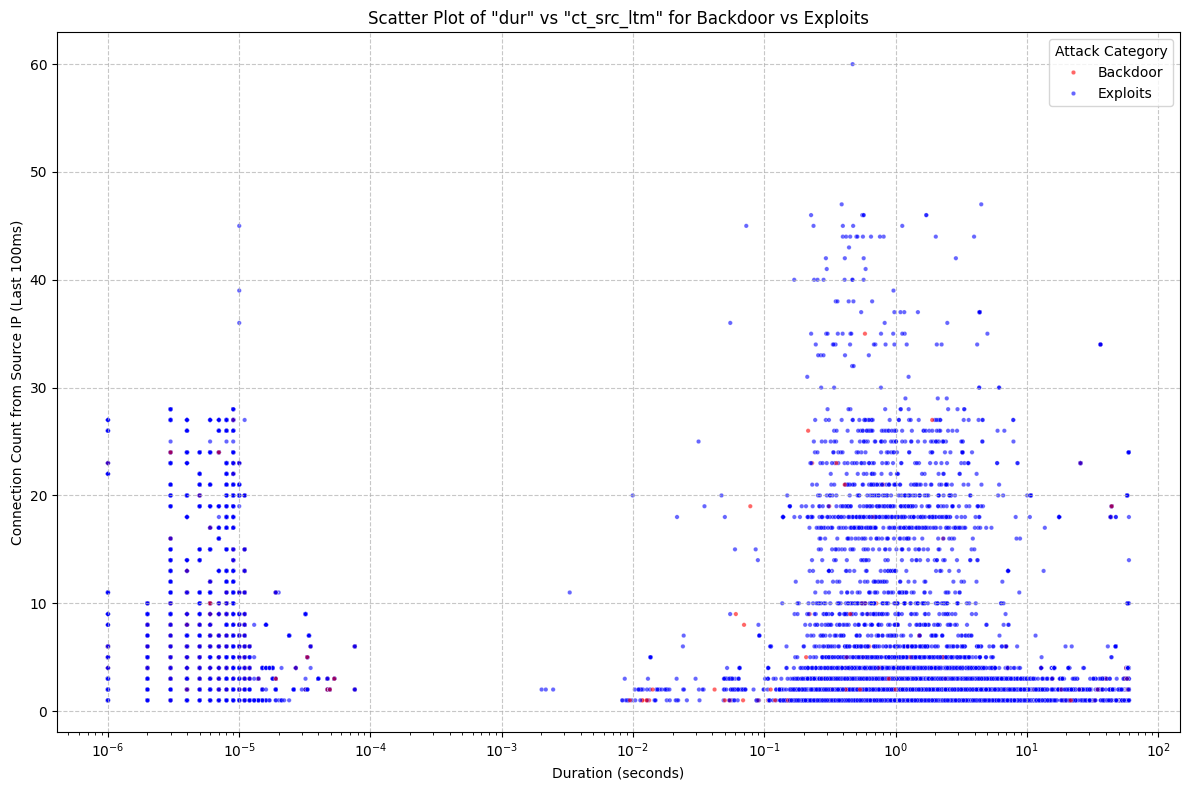

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=binary_df,
    x='dur',
    y='ct_src_ltm',
    hue='attack_cat', # Differentiate 'Backdoor' and 'Exploits' with color
    alpha=0.6,
    s=10, # Adjust marker size for better visibility with many points
    palette={'Backdoor': 'red', 'Exploits': 'blue'}
)

plt.title('Scatter Plot of "dur" vs "ct_src_ltm" for Backdoor vs Exploits')
plt.xlabel('Duration (seconds)')
plt.ylabel('Connection Count from Source IP (Last 100ms)')
plt.xscale('log') # Use log scale for duration as it has a wide range
# plt.yscale('log') # Consider log scale for ct_src_ltm if its range is also very wide
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Attack Category')
plt.tight_layout()
plt.show()

In [28]:
# @title step_artifacts
num_fig = "2" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig)

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import io
import re

# The classification report is available in the previous cell's standard_output
# For demonstration purposes, I will use a hardcoded string of the report output.
# In a real scenario, you would capture this directly from the function's return or stdout.
classification_report_str = """
Detailed Per-Class Category Threat Analysis:
                precision    recall  f1-score   support

      Analysis       0.01      0.03      0.01       677
      Backdoor       0.05      0.53      0.09       583
           DoS       0.29      0.19      0.23      4089
      Exploits       0.74      0.59      0.65     11132
       Fuzzers       0.19      0.46      0.27      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.95      0.63      0.76     37000
Reconnaissance       0.72      0.84      0.78      3496
     Shellcode       0.23      0.73      0.35       378
         Worms       0.39      0.16      0.23        44

      accuracy                           0.67     82332
     macro avg       0.46      0.51      0.44     82332
  weighted avg       0.82      0.67      0.72     82332
"""

# --- Robust parsing of the classification report string ---
report_lines = classification_report_str.strip().split('\n')

# Find the line that contains the metrics headers
header_index = -1
for i, line in enumerate(report_lines):
    if 'precision' in line and 'recall' in line and 'f1-score' in line and 'support' in line:
        header_index = i
        break

if header_index != -1:
    # Extract headers (e.g., 'precision', 'recall', 'f1-score', 'support')
    headers_line = report_lines[header_index].strip()
    # Use a more robust split, assuming at least two spaces separate columns
    headers = [h.strip() for h in re.split(r'\s{2,}', headers_line) if h.strip()]

    data_rows = []
    # Iterate through lines after the header, skipping empty lines and summary rows
    for line_num, line in enumerate(report_lines[header_index + 1:]):
        line = line.strip()
        if not line:  # Skip empty lines
            continue

        # Check if it's a summary line or empty line (which means end of class data)
        if any(keyword in line for keyword in ['accuracy', 'macro avg', 'weighted avg']):
            break

        # Split class name from metrics. Class name can have spaces, but metrics are numbers.
        # The first part is the class name, the rest are numeric metrics.
        parts = [p.strip() for p in re.split(r'\s{2,}', line.lstrip())]

        # The number of metrics is len(headers) (e.g., 4: precision, recall, f1-score, support)
        # So, we expect len(parts) to be len(headers) + 1 (for class name + 4 metrics)
        if len(parts) == len(headers) + 1:
            class_name = parts[0]
            # Convert metrics to float, handling potential errors if any non-numeric data slips in
            metrics_values = []
            for p in parts[1:]:
                try:
                    metrics_values.append(float(p))
                except ValueError:
                    metrics_values.append(np.nan) # Append NaN if conversion fails
            data_rows.append([class_name] + metrics_values)

    # Create DataFrame
    df_report_classes = pd.DataFrame(data_rows, columns=['class'] + headers)
    df_report_classes = df_report_classes.set_index('class')

    # Convert relevant columns to numeric if not already (this also handles NaNs from above)
    for col in headers:
        df_report_classes[col] = pd.to_numeric(df_report_classes[col], errors='coerce')
else:
    print("Error: Could not find classification report headers.")
    df_report_classes = pd.DataFrame() # Initialize empty DataFrame to prevent NameError

display(df_report_classes)

,precision,recall,f1-score,support
class,,,,
Analysis,0.01,0.03,0.01,677.0
Backdoor,0.05,0.53,0.09,583.0
DoS,0.29,0.19,0.23,4089.0
Exploits,0.74,0.59,0.65,11132.0
Fuzzers,0.19,0.46,0.27,6062.0
Generic,1.00,0.97,0.98,18871.0
Normal,0.95,0.63,0.76,37000.0
Reconnaissance,0.72,0.84,0.78,3496.0
Shellcode,0.23,0.73,0.35,378.0


/tmp/ipykernel_1623/3920640462.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha='right') # Set horizontal alignment for labels


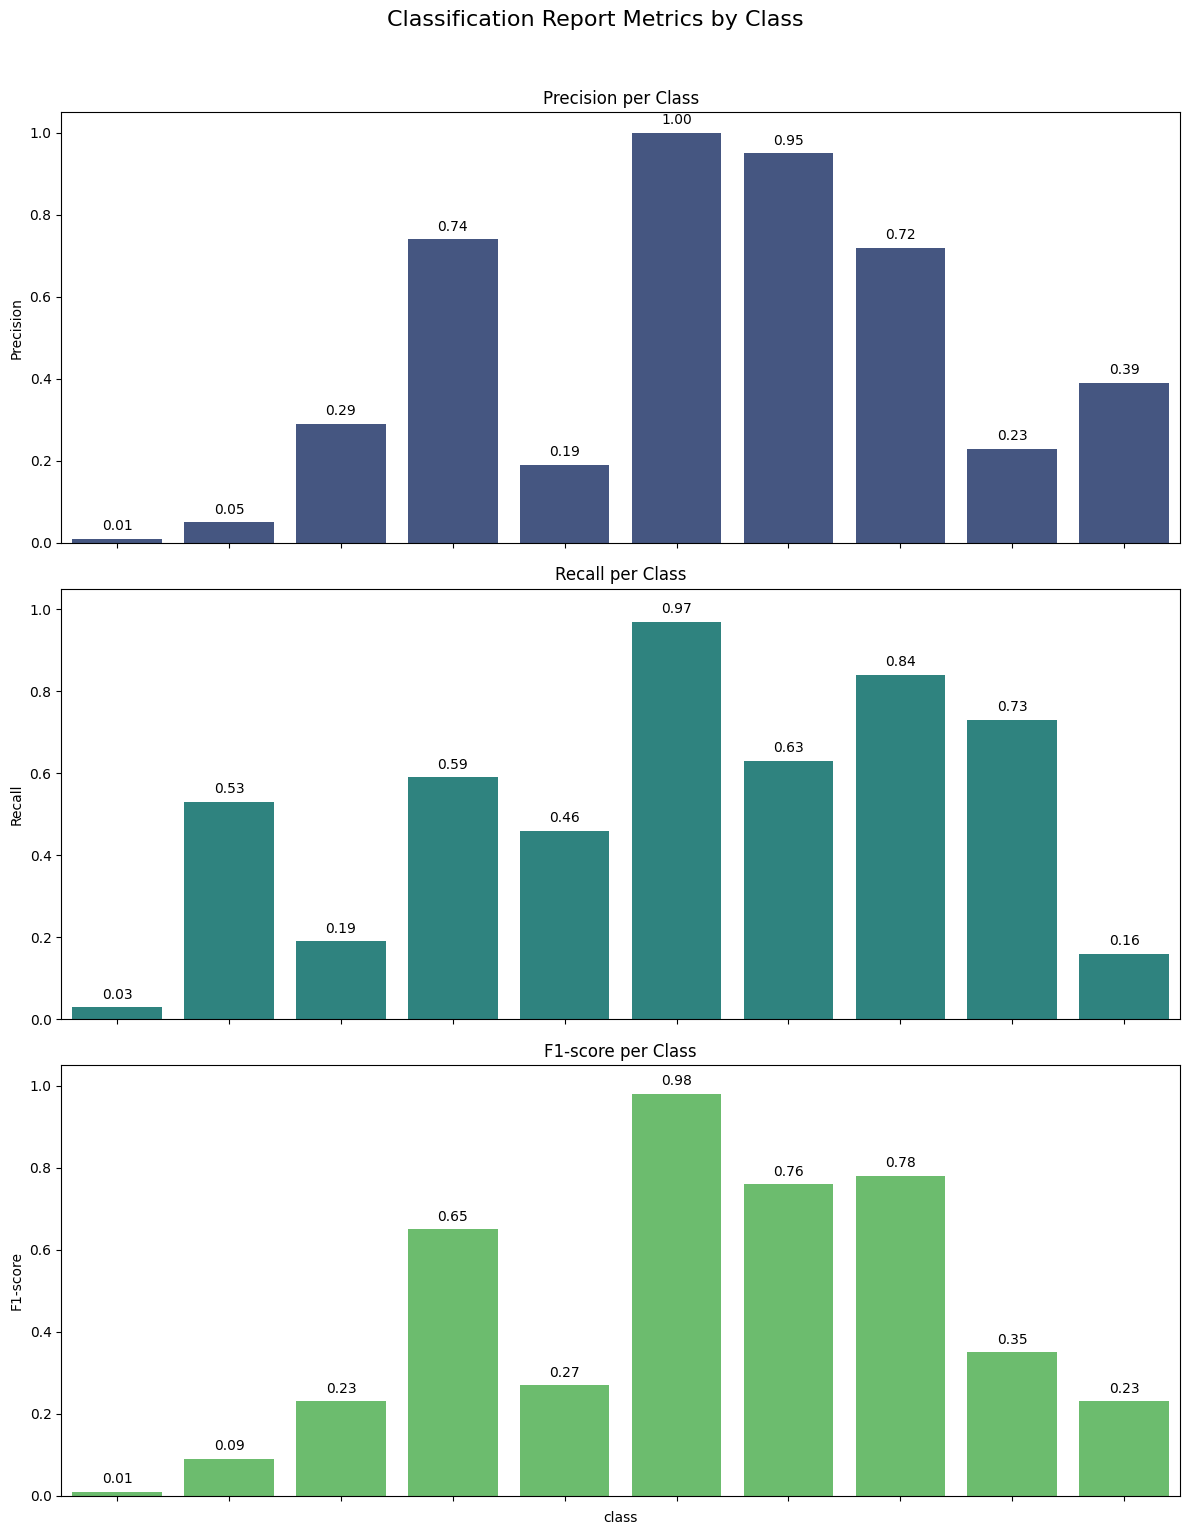

In [25]:
metrics = ['precision', 'recall', 'f1-score']
n_metrics = len(metrics)
n_classes = len(df_report_classes)

fig, axes = plt.subplots(n_metrics, 1, figsize=(12, n_metrics * 5), sharex=True)
fig.suptitle('Classification Report Metrics by Class', y=1.02, fontsize=16)

colors = sns.color_palette('viridis', n_metrics)

for i, metric in enumerate(metrics):
    ax = axes[i]
    # Use 'color' instead of 'palette' to avoid UserWarning when not using 'hue'
    sns.barplot(x=df_report_classes.index, y=metric, data=df_report_classes, ax=ax, color=colors[i])
    ax.set_title(f'{metric.capitalize()} per Class')
    ax.set_ylabel(metric.capitalize())

    # 'ha' is not a parameter for tick_params directly.
    # Instead, set rotation with tick_params and then align labels if needed.
    ax.tick_params(axis='x', rotation=45) # Removed ha='right'
    ax.set_xticklabels(ax.get_xticklabels(), ha='right') # Set horizontal alignment for labels

    ax.set_ylim(0, 1.05) # Metrics are between 0 and 1
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')

plt.tight_layout()
plt.show()